# Exercises 11

In [ ]:
# Imports
from cycler import cycler

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Nadam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.activations import relu, elu, sigmoid, tanh, softsign

import scienceplots

plt.style.use(["science", "ieee"])

colors = plt.cm.Set2.colors
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)

plt.rcParams["figure.dpi"] = 300

***

## Exercise 11.1

Answers for this exercise are just before the next exercise.

In [31]:
# target parameters of f(x) = mx + q
m, q = 2, 1

In [ ]:
# generate training data
np.random.seed(0)

x_train = np.random.uniform(-1, 1, 1048)
x_validation = np.random.uniform(-1, 1, 128)

x_validation.sort()
y_target = m * x_validation + q

sigma = 0.5  # artificial noise
y_train = np.random.normal(m * x_train + q, sigma)
y_validation = np.random.normal(y_target, sigma)

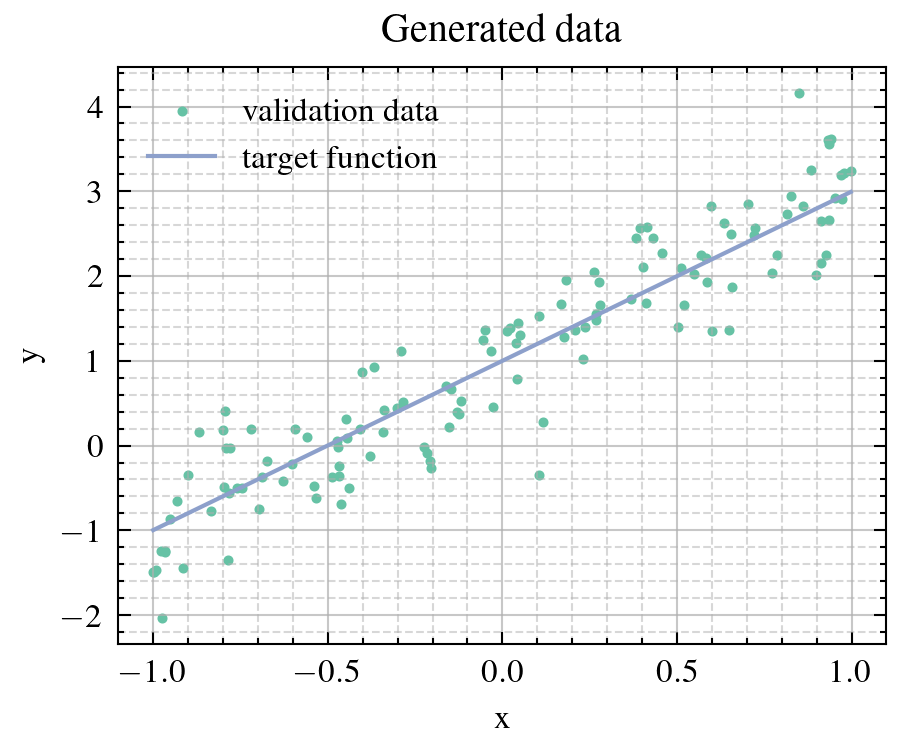

In [ ]:
# show the generated data
plt.scatter(x_validation, y_validation, label="validation data", s=2)
plt.plot(x_validation, y_target, label="target function", c="C2")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Generated data")

plt.legend()
plt.grid(True, which="major", alpha=0.7)
plt.grid(True, which="minor", linestyle="--", alpha=0.5)

plt.show()

To predict a simple line a neural network with just one neuron without activation is enough to resemble the best model possible: $f(x) = wx + q$, where $w$ and $q$ are the neuron parameters to train.

In [ ]:
# create a simple NN model with 1 neuron
model = Sequential()

model.add(Input(shape=(1,)))
model.add(Dense(1))

model.compile(optimizer=SGD(), loss=MeanSquaredError())

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# train the model
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_validation, y_validation),
    shuffle=True,
    epochs=30,
    batch_size=32,
    verbose=1,
)

Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0049 - val_loss: 0.7324
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - loss: 0.5121 - val_loss: 0.4691
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step - loss: 0.3550 - val_loss: 0.3707
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 724us/step - loss: 0.2963 - val_loss: 0.3252
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 724us/step - loss: 0.2699 - val_loss: 0.2995
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - loss: 0.2562 - val_loss: 0.2832
Epoch 7/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step - loss: 0.2480 - val_loss: 0.2719
Epoch 8/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step - loss: 0.2427 - val_loss: 0.2641
Epoch 9/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 718us/step - loss: 0.2395 - val_loss: 0.2585
Epoch 10/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 709us/step - loss: 0.2375 - val_loss: 0.2545
Epoch 11/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step - loss: 0.2363 - val_loss: 0.2517
Epoch 12/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step -

In [ ]:
# show the weights of the trained model
model.get_weights()

[array([[1.963617]], dtype=float32), array([1.0175129], dtype=float32)]

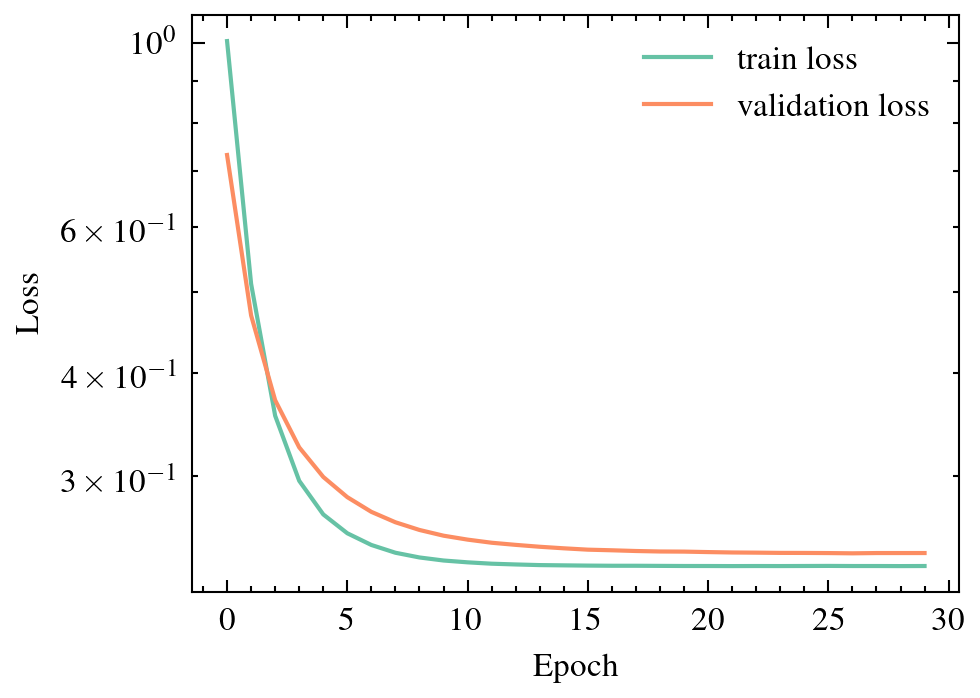

In [ ]:
# plot the loss curve
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")

plt.title("Loss curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.yscale("log")

plt.legend()
plt.grid(True, which="major", alpha=0.7)
plt.grid(True, which="minor", linestyle="--", alpha=0.5)

plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


[]

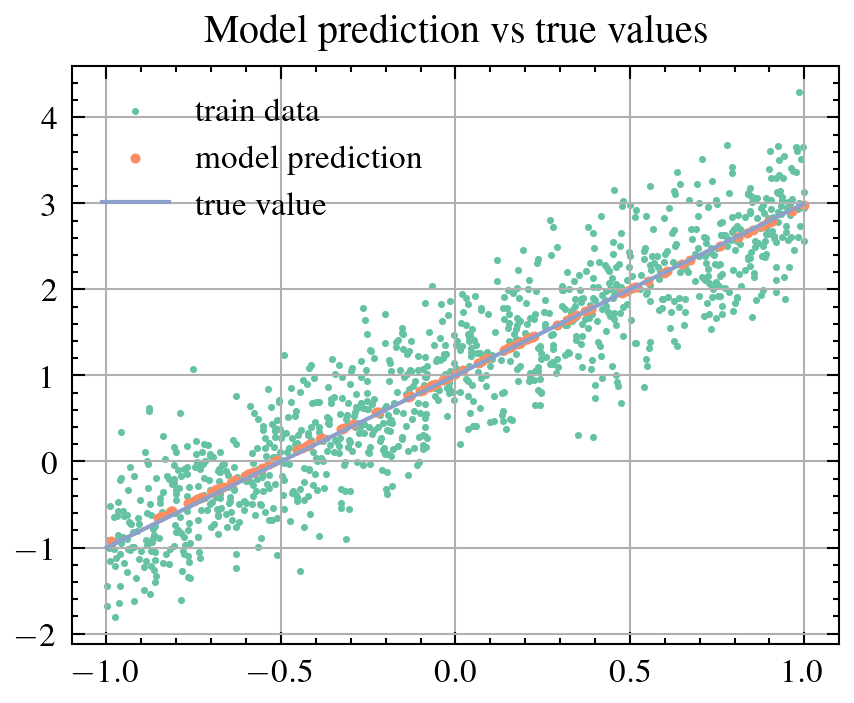

In [ ]:
x_pred = np.random.uniform(-1, 1, 100)
y_pred = model.predict(x_pred)

plt.scatter(x_train, y_train, label="train data", s=0.5)
plt.scatter(x_pred, y_pred, label="model prediction", s=2)
plt.plot(x_validation, y_target, label="true value", c="C2")

plt.title("Model prediction vs true values")
plt.xlabel("x")
plt.ylabel("y")

plt.legend()
plt.grid(True, which="major", alpha=0.7)
plt.grid(True, which="minor", linestyle="--", alpha=0.5)

plt.plot()

By playing a bit with the parameters: $N_\text{epochs}$, $N_\text{train}$ and $\sigma$, we can get some rough conclusions:
1. By increasing $N_\text{epochs}$ the results generally improve until overfitting starts to appear. During the first epochs the network is still learning the underlying linear relation, therefore both training and validation losses decrease. After a certain point, however, the network starts adapting not only to the true relation but also to the random fluctuations present in the training set. As a consequence the training loss keeps decreasing while the validation loss stops improving or may even increase. This effect is more evident when the data are noisy.

    Increasing $N_\text{epochs}$ also increases the computational cost of training, so a larger number of epochs is not always beneficial.

2. By increasing $N_\text{train}$ the results generally improve since the network learns more about the underlying structure of the data and less about the statistical fluctuations of individual samples. A larger training set provides a better estimate of the true data distribution and reduces the variance of the model. As a consequence the predictions become more stable and the gap between training and validation performance is usually reduced. It is worth noting that in many real applications obtaining additional data can be expensive or even impossible, while in our case generating synthetic data is essentially cost-free. 

    Also shuffling data before each epoch is very important for stochastic optimizers, since without shuffling the noise of each batch is always in the same direction, leading to worse results.

    The main drawback of increasing $N_\text{train}$ is that increasing the amount of training data also increases the computational cost of each epoch.

3. By increasing the noise $\sigma$ we obtain worse results. As expected, when the data contain more noise it becomes harder for the network to identify the true underlying relation. Part of the observed variability is purely random and therefore cannot be predicted by any model. This is closely related to the concept of irreducible error: even with the optimal model and an infinite amount of training data, a certain minimum error remains because the target values themselves are affected by noise. For this reason the losses never reach zero when $\sigma > 0$. Furthermore, larger noise levels make overfitting more likely, since the model may start learning random fluctuations that are specific to the training sample rather than the true trend.

Overall, the best results are obtained with low-noise data, a sufficiently large training set, and a number of epochs that is large enough for convergence but small enough to avoid overfitting. In practice, a common strategy is to train for many epochs and rely on early stopping to select the optimal number of epochs.

***

## Exercise 11.2

In [40]:
# define the function we want to use to generate data
def f(x):
    return 4 - 3 * x - 2 * x**2 + 3 * x**3

In [41]:
# parameters for data generation
sigma = 0.5

N_train = 2**13
N_validation = 2**10

# Generate data
x_train = np.random.uniform(-1, 1, N_train)
y_train = f(x_train) + np.random.normal(0, sigma, N_train)

x_validation = np.random.uniform(-1, 1, N_validation)
y_validation = f(x_validation) + np.random.normal(0, sigma, N_validation)

In [ ]:
# create a new NN model with 2 hidden layers of 20 neurons each
model = Sequential()

model.add(Input(shape=(1,)))
model.add(Dense(20, activation=relu))
model.add(Dense(20, activation=relu))
model.add(Dense(1))

model.compile(optimizer=Adam(), loss=MeanSquaredError())

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 20)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# train the new model
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_validation, y_validation),
    shuffle=True,
    epochs=30,
    batch_size=64,
)

Epoch 1/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 809us/step - loss: 6.6553 - val_loss: 1.9135
Epoch 2/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 415us/step - loss: 1.3707 - val_loss: 0.9907
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step - loss: 0.8150 - val_loss: 0.6087
Epoch 4/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step - loss: 0.5264 - val_loss: 0.4128
Epoch 5/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 426us/step - loss: 0.3920 - val_loss: 0.3295
Epoch 6/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step - loss: 0.3292 - val_loss: 0.2917
Epoch 7/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step - loss: 0.2982 - val_loss: 0.2728
Epoch 8/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step - loss: 0.2823 - val_loss: 0.2665
Epoch 9/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 417us/step - loss: 0.2728 - val_loss: 0.2549
Epoch 10/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - loss: 0.2668 - val_loss: 0.2513
Epoch 11/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step - loss: 0.2621 - val_loss: 0.2496
Epoch 12/30
128/128 ━━━━━━━━━━

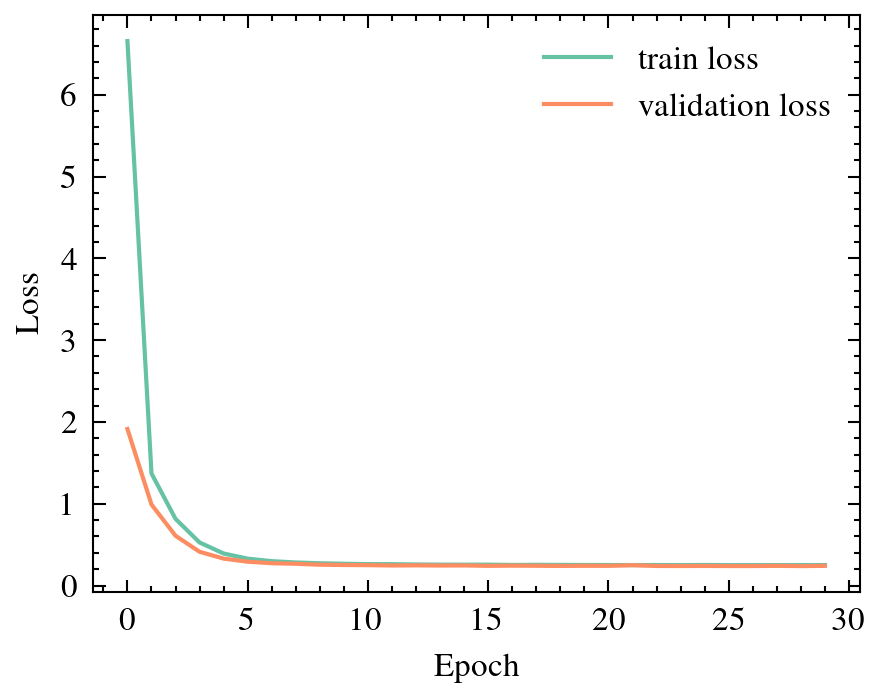

In [ ]:
# plot the loss curve
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")

plt.title("Loss curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(True, which="major", alpha=0.7)
plt.grid(True, which="minor", linestyle="--", alpha=0.5)

plt.show()

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/stepWARNING:tensorflow:5 out of the last 667 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x14abc89a0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


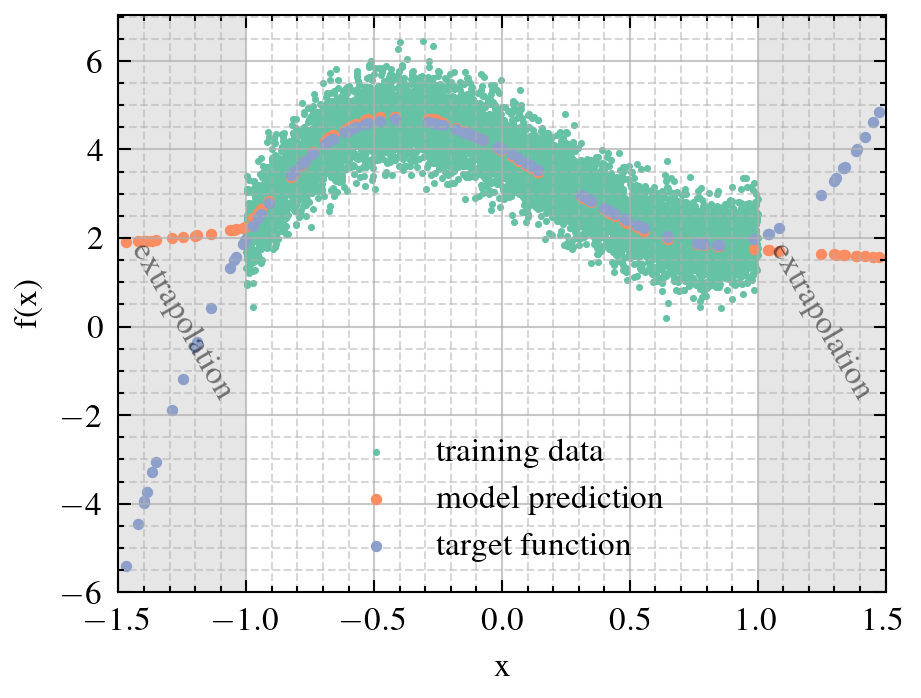

In [ ]:
# show the model prediction vs the target function
x_test = np.random.uniform(-1.5, 1.5, 100)
y_test = model.predict(x_test)
y_target = f(x_test)

plt.scatter(x_train, y_train, label="training data", s=0.5, alpha=0.7)
plt.scatter(x_test, y_test, label="model prediction", s=3)
plt.scatter(x_test, y_target, label="target function", s=3)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Model Prediction vs Target Function")

# add the extrapolation area
plt.axvspan(1.0, 1.7, color="0.90", lw=0, zorder=-1)
plt.text(1.03, -1.6, "extrapolation", rotation=-60, alpha=0.5)
plt.axvspan(-1.7, -1.0, color="0.90", lw=0, zorder=-1)
plt.text(-1.47, -1.6, "extrapolation", rotation=-60, alpha=0.5)

plt.xlim(-1.5, 1.5)

plt.legend()
plt.grid(True, which="major", alpha=0.7)
plt.grid(True, which="minor", linestyle="--", alpha=0.5)

plt.show()

### Number of layers and neurons in each layer

By the universal approximation theorems we know that by increasing the number of neurons in a layer or increasing the number of layers (or both) we can approximate any function we are interested in, by increasing the number of parameters we increase the ability of the NN to learn more complex behaviors. However if we increase the number of free parameters of our model it becomes prone to overfitting, so we must avoid having too few or too many parameters to train.

For our case i found that a simple network of 2 layers both with 20 neurons each works quite good. Another valid alternative is a network with just one layer of 400 neurons is also good.
For "good results" I mean to find a loss near $\sigma^2 = 0.25$.

### Activation functions

I tested different activation functions: relu, elu, sigmoid, tanh and softsign; all of them reach convergence sooner or later, but sigmoid is significantly worse than the others. 

In my test the relu activation gave me convergence with the fewest epochs. It is to note that even if relu is faster, it gives sharper results than the others, which give smoother results for the predictions.

### Optimizers

I have tested: SGD, Adam, RMSprop and Nadam all of them converge to the same solution, but SGD is a bit slower to converge. 
On the other end SGD requires less computational cost being 10-20% faster than the others per epoch and not requiring to store momentum or acceleration, which require double (RMSprop) or triple (Adam, Nadam) the memory for the NN.

Overall the choice of optimizer depends on memory, if we are able to store the momentum and acceleration of Adam/Nadam these can be more efficient, otherwise if we need to use a large NN we could be forced to use SGD for memory requirements.

### Loss function

From the maximum likelyhood principle is has been proven that for a regression problem the best loss function $L$ is the mean squared error defined as:
$$
L = \frac{1}{N}\sum_N \left(\hat f(\vec x) - y\right)^2
$$
While for a classification problem the best loss function is the categorical crossentropy:
$$
L = \frac{1}{N}\sum_N \sum_{i=1}^k -y_i \log \left(\hat f(\vec x)\right)
$$
Where in both $N$ is the number of data points, $\hat f$ is our predictor, $y$ are the correct values and $i$ is the one of the $k$ categories.

### Behavior outside the data

We can see that outside the input range the NN did not perform well, that's because NN **do not** have extrapolation power and should not be used outside their training domain.

***

## Exercise 11.3

To make our model learn:

$$
f(x, y) = \sin(x^2 + y^2) 
$$

We can simply extend the previous exercise to accept a input of shape: $(2, )$ as our vector $(x, y)$. Also we will probably need to increase the number of layers/neurons a bit since this function is a bit more complex.

In [ ]:
# define the function we want to use to generate data
def f(x):
    return np.sin(x[:, 0] ** 2 + x[:, 1] ** 2)

In [ ]:
# parameters for data generation
sigma = 0.5

N_train = 2**14
N_validation = 2**11

# Generate data
x_train = np.random.uniform(-3 / 2, 3 / 2, (N_train, 2))
y_train = f(x_train) + np.random.normal(0, sigma, N_train)

x_validation = np.random.uniform(-3 / 2, 3 / 2, (N_validation, 2))
y_validation = f(x_validation) + np.random.normal(0, sigma, N_validation)

For our model i kept the relu activation, the Adam optimizer, and the MSE loss, but I increased the number of layers to 3 with 30 neurons each.

In [ ]:
# create a new NN model with 3 hidden layers of 30 neurons each
model = Sequential()

model.add(Input(shape=(2,)))
model.add(Dense(30, activation=relu))
model.add(Dense(30, activation=relu))
model.add(Dense(30, activation=relu))
model.add(Dense(1))

model.compile(optimizer=Adam(), loss=MeanSquaredError())

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 30)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,981 (7.74 KB)

 Trainable params: 1,981 (7.74 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# train the model
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_validation, y_validation),
    shuffle=True,
    epochs=30,
    batch_size=128,
)

Epoch 1/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 881us/step - loss: 0.4272 - val_loss: 0.3858
Epoch 2/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step - loss: 0.3580 - val_loss: 0.3489
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step - loss: 0.3155 - val_loss: 0.3006
Epoch 4/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 450us/step - loss: 0.2834 - val_loss: 0.2767
Epoch 5/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step - loss: 0.2681 - val_loss: 0.2626
Epoch 6/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step - loss: 0.2623 - val_loss: 0.2616
Epoch 7/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step - loss: 0.2575 - val_loss: 0.2577
Epoch 8/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 437us/step - loss: 0.2555 - val_loss: 0.2568
Epoch 9/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step - loss: 0.2558 - val_loss: 0.2585
Epoch 10/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step - loss: 0.2550 - val_loss: 0.2596
Epoch 11/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - loss: 0.2555 - val_loss: 0.2546
Epoch 12/30
128/128 ━━━━━━━━━━

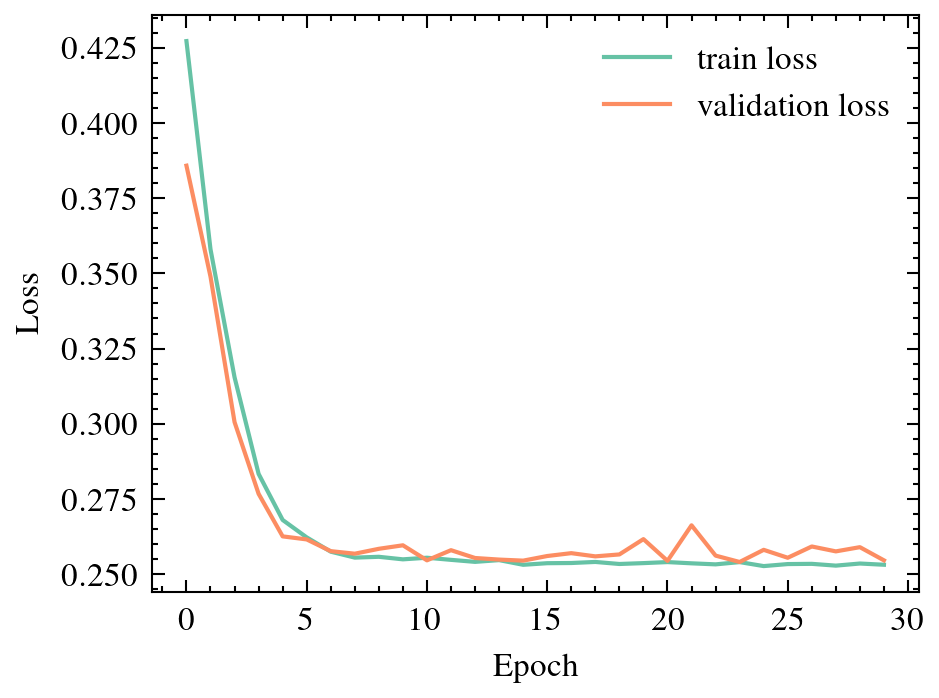

In [ ]:
# plot the loss curve
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss curve")

plt.legend()
plt.grid(True, which="major", alpha=0.7)
plt.grid(True, which="minor", linestyle="--", alpha=0.5)

plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 443us/step


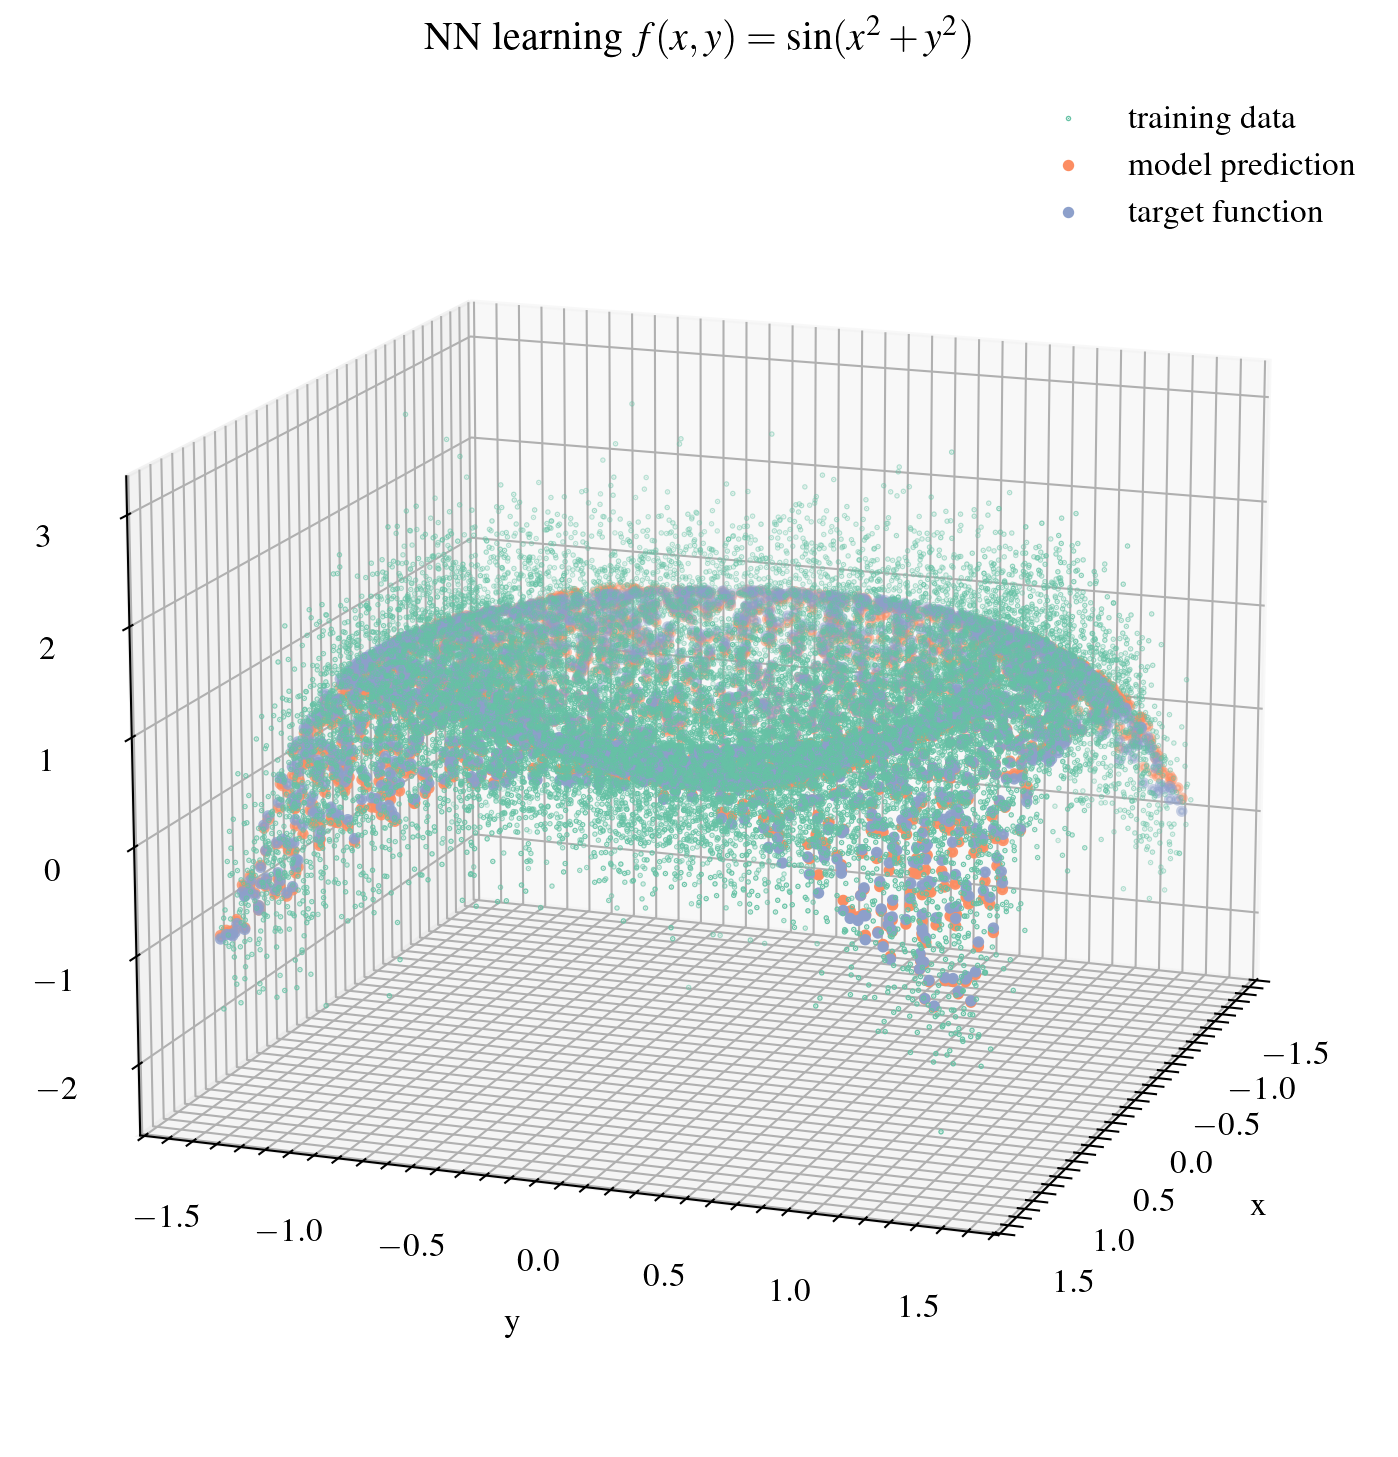

In [52]:
x_test = np.random.uniform(-1.5, 1.5, (3000, 2))
y_test = model.predict(x_test)
y_target = f(x_test)

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    x_train[:, 0],
    x_train[:, 1],
    zs=y_train,
    zdir="z",
    label="training data",
    s=0.1,
)
ax.scatter(
    x_test[:, 0], x_test[:, 1], zs=y_test.T, zdir="z", label="model prediction", s=3
)
ax.scatter(
    x_test[:, 0], x_test[:, 1], zs=y_target, zdir="z", label="target function", s=3
)

ax.set_title(r"NN learning $f(x, y) = \sin(x^2+y^2)$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel(r"$f(x, y)$")

ax.legend()
ax.grid(True, which="major", alpha=0.7)
ax.grid(True, which="minor", linestyle="--", alpha=0.5)

ax.view_init(elev=15, azim=20)

plt.tight_layout()
plt.show()

We can see that the model learned the function quite well even if the data is a bit noisy.